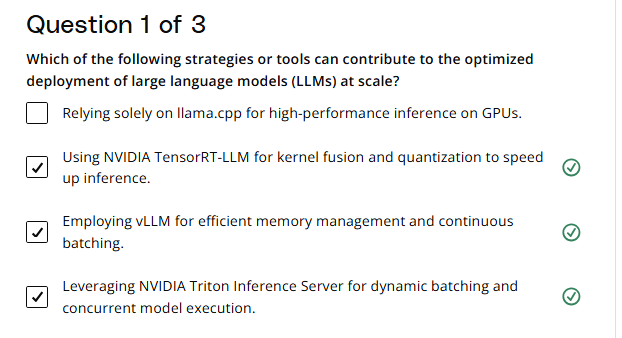

# Optimized Deployment & Inference Serving for LLMs

After optimizing a model (quantization, pruning, parallelism, KV cache optimization), the next challenge is:

> **How do we serve the model efficiently to real users at production scale?**

This is handled using specialized **LLM inference and serving frameworks**.

---

# Main Production Challenges in LLM Serving

| Challenge               | Description                         |
| ----------------------- | ----------------------------------- |
| High latency            | Token generation can be slow        |
| GPU memory limits       | Large models consume huge VRAM      |
| Concurrent users        | Many requests arrive simultaneously |
| Throughput optimization | Need maximum tokens/sec             |
| Multi-GPU scaling       | Models may not fit on one GPU       |
| Dynamic batching        | Efficiently combine requests        |
| Deployment management   | Versioning, rollout, monitoring     |
| Cost efficiency         | Reduce infrastructure cost          |

---

# Major LLM Serving Frameworks

| Tool                           | Main Focus                  | Best For                       |
| ------------------------------ | --------------------------- | ------------------------------ |
| NVIDIA TensorRT-LLM            | GPU inference optimization  | Maximum NVIDIA GPU performance |
| NVIDIA Triton Inference Server | Production model serving    | Scalable deployment            |
| vLLM                           | High-throughput LLM serving | Fast batching + serving        |
| llama.cpp                      | CPU/local inference         | Edge + local deployments       |

---

# 1. TensorRT-LLM

## What It Is

An open-source framework from NVIDIA for:

* Optimizing LLM inference
* Compiling models into highly optimized GPU engines
* Running ultra-fast inference on NVIDIA GPUs

---

# TensorRT-LLM Pipeline

| Step                    | Description                                 |
| ----------------------- | ------------------------------------------- |
| Load PyTorch/JAX model  | Import trained model                        |
| Compile using TensorRT  | Convert into optimized engine               |
| Apply optimizations     | Quantization, kernel fusion, FlashAttention |
| Generate runtime engine | Hardware-specific optimized engine          |
| Deploy on GPUs          | High-speed inference                        |

---

# Key Optimizations

| Optimization            | Purpose                         |
| ----------------------- | ------------------------------- |
| Kernel Fusion           | Reduce GPU overhead             |
| INT8 / FP8 Quantization | Faster inference + lower memory |
| Flash Attention         | Faster attention computation    |
| KV Cache Optimization   | Faster token generation         |
| Tensor Parallelism      | Split model across GPUs         |
| Pipeline Parallelism    | Layer-wise GPU distribution     |

---

# Tensor Parallelism Example

| GPU 1                     | GPU 2               |
| ------------------------- | ------------------- |
| Part of attention weights | Remaining weights   |
| Partial computation       | Partial computation |
| Combined later            | Combined later      |

---

# Advantages

| Benefit                        | Explanation                 |
| ------------------------------ | --------------------------- |
| Maximum NVIDIA GPU utilization | Extremely optimized kernels |
| Low latency                    | Faster token generation     |
| Multi-GPU support              | Large model serving         |
| Enterprise-ready               | Production-grade deployment |

---

# Limitation

| Issue                 | Reason                                |
| --------------------- | ------------------------------------- |
| NVIDIA GPU dependent  | Built specifically for CUDA ecosystem |
| More setup complexity | Requires engine compilation           |

---

# 2. Triton Inference Server

## What It Is

NVIDIA Triton Inference Server is a production-grade inference server for deploying AI models at scale.

It supports:

* PyTorch
* TensorFlow
* ONNX
* TensorRT
* TensorRT-LLM

---

# Triton Architecture

```text
Client Requests
       ↓
Triton Server
       ↓
Dynamic Batching
       ↓
GPU Scheduling
       ↓
Model Execution
       ↓
Responses
```

---

# Core Features

## 1. Concurrent Model Execution

Run:

* Multiple models
* Multiple model instances
* Multiple user requests

simultaneously.

---

## 2. Dynamic Batching

### Problem

Small batches waste GPU power.

### Solution

Triton automatically groups requests.

---

## Example

| Incoming Requests | Batched Together   |
| ----------------- | ------------------ |
| Req1              |                    |
| Req2              | → Single GPU Batch |
| Req3              |                    |

Result:

* Better GPU utilization
* Higher throughput

---

## 3. Model Versioning

| Version | Status  |
| ------- | ------- |
| v1      | Active  |
| v2      | Testing |
| v3      | Rollout |

Enables:

* Zero downtime deployment
* Safe upgrades
* A/B testing

---

## 4. Multi-GPU Orchestration

Triton distributes:

* requests
* models
* batches

across multiple GPUs.

---

# Triton Strengths

| Strength                | Benefit               |
| ----------------------- | --------------------- |
| Production serving      | Enterprise deployment |
| Auto batching           | Higher throughput     |
| Multi-framework support | Flexible deployment   |
| Scalable                | Handles large traffic |

---

# TensorRT-LLM + Triton Together

Very common production setup.

---

## Workflow

```text
PyTorch Model
      ↓
TensorRT-LLM Optimization
      ↓
Optimized TensorRT Engine
      ↓
Triton Inference Server
      ↓
Production Traffic
```

---

# 3. vLLM

## What It Is

vLLM is designed specifically for:

* Fast LLM inference
* High throughput
* Efficient memory handling

---

# Core Innovation: PagedAttention

## Traditional KV Cache Problem

Memory fragmentation:

```text
Free memory exists
BUT
not as one continuous block
```

This limits:

* batch size
* throughput

---

# PagedAttention Solution

Inspired by:

* Operating system virtual memory
* Paging systems

---

## Instead of:

```text
One large continuous KV cache
```

## vLLM uses:

```text
Small independent memory pages
```

---

# Benefits

| Benefit                | Result                   |
| ---------------------- | ------------------------ |
| Less fragmentation     | Better memory efficiency |
| Larger batches         | Higher throughput        |
| Better GPU utilization | Faster serving           |

---

# Continuous Batching

## Traditional Batching

```text
Wait for full batch completion
```

## Continuous Batching

```text
Finished requests leave
New requests enter immediately
```

---

# Result

| Metric          | Improvement |
| --------------- | ----------- |
| GPU utilization | Higher      |
| Throughput      | Much higher |
| Idle GPU time   | Lower       |

---

# Additional Features

| Feature               | Purpose             |
| --------------------- | ------------------- |
| Tensor Parallelism    | Multi-GPU inference |
| OpenAI-compatible API | Easy integration    |
| Fast token serving    | Low latency         |

---

# Why vLLM Became Popular

| Reason                    | Explanation           |
| ------------------------- | --------------------- |
| Very high throughput      | Excellent batching    |
| Easy deployment           | OpenAI API compatible |
| Efficient KV cache        | PagedAttention        |
| Strong community adoption | Widely used           |

---

# 4. llama.cpp

## What It Is

llama.cpp enables efficient LLM inference on:

* CPUs
* laptops
* edge devices
* consumer hardware

---

# Key Techniques

## 1. Quantization

Uses:

* 4-bit
* 5-bit
* low precision formats

---

## Result

| Before            | After            |
| ----------------- | ---------------- |
| Huge memory usage | Much smaller     |
| Slower inference  | Faster inference |

---

# 2. Optimized C++

Written in highly optimized C++ using:

* AVX
* AVX2
* AVX-512

CPU vector instructions accelerate computation.

---

# 3. Optional GPU Offloading

Even though CPU-focused:

* some layers can run on GPU
* hybrid inference possible

---

# Best Use Cases

| Use Case            | Why llama.cpp     |
| ------------------- | ----------------- |
| Local AI assistant  | Runs on laptops   |
| Edge deployment     | No GPU required   |
| Offline inference   | Fully local       |
| Low-cost deployment | CPU-based serving |

---

# Comparison of All Frameworks

| Framework    | Hardware           | Main Strength         | Best Use Case            |
| ------------ | ------------------ | --------------------- | ------------------------ |
| TensorRT-LLM | NVIDIA GPU         | Maximum optimization  | Enterprise GPU inference |
| Triton       | GPU/CPU            | Production serving    | Scalable deployment      |
| vLLM         | GPU                | High throughput       | Chat/API serving         |
| llama.cpp    | CPU + optional GPU | Lightweight inference | Local/edge AI            |

---

# Typical Production Architectures

## Option 1: NVIDIA Enterprise Stack

```text
PyTorch
   ↓
TensorRT-LLM
   ↓
Triton Server
   ↓
Production APIs
```

Best for:

* enterprise GPU clusters
* ultra-low latency

---

## Option 2: High Throughput Serving

```text
LLM
 ↓
vLLM
 ↓
OpenAI-compatible API
 ↓
Applications
```

Best for:

* chatbots
* API serving
* many concurrent users

---

## Option 3: Local AI

```text
Quantized Model
      ↓
llama.cpp
      ↓
Laptop / Edge Device
```

Best for:

* offline AI
* private inference
* low-cost deployment

---

# Decision Guide

| Requirement                    | Best Choice  |
| ------------------------------ | ------------ |
| Maximum NVIDIA GPU performance | TensorRT-LLM |
| Enterprise deployment platform | Triton       |
| Highest throughput serving     | vLLM         |
| CPU-only deployment            | llama.cpp    |
| Edge AI                        | llama.cpp    |
| OpenAI-compatible serving      | vLLM         |
| Multi-model serving            | Triton       |

---

# Key Production Concepts

| Concept              | Meaning                      |
| -------------------- | ---------------------------- |
| Throughput           | Tokens/sec served            |
| Latency              | Time per response            |
| Batching             | Combining requests           |
| KV Cache             | Stores past attention states |
| Tensor Parallelism   | Split tensors across GPUs    |
| Pipeline Parallelism | Split layers across GPUs     |
| Quantization         | Lower precision weights      |
| Dynamic Batching     | Real-time batch creation     |

---

# Final Big Picture

```text
Train Model
    ↓
Optimize Model
(Quantization, Parallelism, Compression)
    ↓
Inference Optimization
(TensorRT-LLM / vLLM)
    ↓
Serving Layer
(Triton / API Server)
    ↓
Production Applications
(Chatbots, APIs, Agents)
```

---

# Simple Intuition

| Tool         | Simple Analogy                 |
| ------------ | ------------------------------ |
| TensorRT-LLM | Formula 1 engine tuning        |
| Triton       | Traffic management system      |
| vLLM         | Smart memory-efficient highway |
| llama.cpp    | Lightweight portable engine    |
